# Imports

In [1]:
suppressMessages({
    Sys.setenv(RETICULATE_PYTHON = "/ihome/rbao/bri8/envs/r_seurat5.2/bin/python")
    library(reticulate)
    library(dplyr)
    library(arrow)
    library(patchwork)
    library(hdf5r)
    library(anndata)
    library(ggplot2)
    library(ggpubr)
    library(ggrepel)
    library(future)
    library(Seurat)
    library(pheatmap)
    library(RColorBrewer)
    library(SingleR)
    library(stringr)
    library(sf)
    library(purrr)
   })
task_id <- as.integer(Sys.getenv("SLURM_ARRAY_TASK_ID", "1"))
node <- Sys.getenv("SLURM_JOB_NODELIST","1")
num_workers = as.integer(Sys.getenv("SLURM_CPUS_PER_TASK","4"))
print(paste('Task:',task_id,"on",node,'num_workers',num_workers))
options(future.globals.maxSize = (256/num_workers)* 1024^3,
       future.seed=TRUE) 
plan("multisession", workers = num_workers)  
plan("default")

prj = "HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq"
base = file.path('/ix/rbao/Projects', prj)
scripts= file.path(base,'scripts')
results = file.path(base,'results','visium')
sampleinfo = file.path(base,'sampleinfo')
data = file.path(base,'data','visium','spaceranger')
issues_marked <- file.path(results,'cloupe_region_exlcusions')
info = read.csv(file.path(sampleinfo,'32_visium_tissue_positions_paths.csv'))
df=  read.table(file.path(sampleinfo,'55_combined_sample_info_062525_bi_32_vis_23_chrom.tsv'),
                header =2,
                sep = '\t')
head(info,n=3)
head(df,n=3)

[1] "Task: 1 on htc-n30 num_workers 1"


,X,Unnamed..0.1,Unnamed..0,sample_name,csv_path,json_path,svs_path,visium_dir,regist_target_img_scalef,tissue_hires_scalef,tissue_lowres_scalef,fiducial_diameter_fullres,spot_diameter_fullres
,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,0,0,25_0065,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0065_done/25_0065/outs/spatial/tissue_positions.csv,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0065_done/25_0065/outs/spatial/scalefactors_json.json,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0065_done/25_0065_vis.svs,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0065_done/25_0065/outs,0.7512208,0.25040692,0.07512207,25.77433,17.18289
2,1,1,1,25_0066,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0066_done/25_0066/outs/spatial/tissue_positions.csv,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0066_done/25_0066/outs/spatial/scalefactors_json.json,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0066_done/25_0066_vis.svs,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0066_done/25_0066/outs,0.1960848,0.06536161,0.01960848,104.52780,69.68520
3,2,2,2,25_0067,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0067_done/25_0067/outs/spatial/tissue_positions.csv,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0067_done/25_0067/outs/spatial/scalefactors_json.json,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0067_done/25_0067_vis.svs,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0067_done/25_0067/outs,0.2429346,0.08097822,0.02429347,415.94381,277.29587


,Original.ID,CGF.ID,Pool.ID,Status,Human.WTA.Probes,Smoking.Status,any_tobacco_smoker,current_smoker,response_status,Assay,CGF.Sample.ID,HTGC.Sample.ID,Visium.Slide.Position..A1.or.D1..in.Cytassist,Slide.orientation.in.Cytassist,Estimated...Cover..Cytassist.,Index.name,Index..i7..sequence,Index..a_i5.,Index..b_i5.,group
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,21-091-003,25_0113,Cure_002_pool,Pass,BC002,never,no,no,,chromium,,NA,,,NA,,,,,21-091
2,21-091-004,25_0114,Cure_001_pool,Pass,BC016,"patient CTB 1/21/24 - per EPIC, former smoker 1991-2011",yes,no,,chromium,,NA,,,NA,,,,,21-091
3,21-091-005,25_0115,Cure_002_pool,Pass,BC003,patient CTB 4/9/24 - per EPIC never smoked,no,no,,chromium,,NA,,,NA,,,,,21-091


# Functions

In [2]:
save.figs <- function(p1,out.dir,base.fn,width,height){
    fn=paste0(base.fn,'.png')
    ggsave(file.path(out.dir,fn),
           plot = p1,
           width = width,
           height = height,
           units = 'in')
    fn=paste0(base.fn,'.pdf')
    ggsave(file.path(out.dir,fn),
           plot = p1,
           width = width,
           height = height,
           units = 'in')
}
volcano.plot <- function(de,p_thresh,log_thresh,title){
    max_abs_x <- max(abs(de$log2FC))
    suppressWarnings({
        p1 <- ggplot(data=de, aes(x=log2FC, y=-log10(p.adj+1e-300), col=diffexpressed, label=delabel)) +
                    geom_point() + 
                    theme_minimal() +
                    geom_text_repel() +
                    scale_color_manual(values=c("blue", "black", "red")) +
                    geom_vline(xintercept=c(-log_thresh, log_thresh), col="red") +
                    geom_hline(yintercept=-log10(p_thresh), col="red") +
                    ggtitle(title) +  xlim(-1.05 * max_abs_x, 1.05 * max_abs_x)
    })

    return(p1)
    }

heatmap.plot <- function(de,sub,title, ds.pt = 100,
                         ndeg_top_bottom=15, 
                         p.thresh=0.05,
                         plot.tag = c('response_status','any_tobacco_smoker')
                         ){

    DefaultAssay(sub) <- "Spatial"
    Idents(object=sub) <- 'cgf.sample.id'
    suppressWarnings({sub <- subset(sub, downsample = ds.pt)})
    DefaultAssay(sub) <- "Spatial"
    exclude.tma <- df[grepl(pattern = 'TMA',x = df$Original.ID),'CGF.Sample.ID']
    annotation_col <- sub@meta.data %>% filter(!(cgf.sample.id %in% exclude.tma)) %>%
      filter(row.names(.) %in% colnames(sub) ) %>%
      select(all_of(plot.tag)) #cgf.sample.id, 
    ndeg = ndeg_top_bottom
    de %>% filter(p_val_adj <  p.thresh) %>% filter(avg_log2FC >0 ) %>%
                top_n(n = ndeg, wt =  avg_log2FC) -> top
    de %>% filter(p_val_adj <  p.thresh) %>% filter(avg_log2FC <0) %>%
                top_n(n = ndeg, wt = -avg_log2FC) -> bottom
    temp <- rbind(top,bottom)
    use.genes <- unique(temp$Gene)  
    lognorm.dat <- as.matrix(sub@assays$Spatial$data[use.genes,
                                                     row.names(annotation_col),
                                                     drop = FALSE])
    if (length(use.genes) <= 1){
        return(NA)
    }
    ann_colors <- smoker.ann.colors(plot.tag)
    # 5. Plot with pheatmap (row scaling built-in)
     p1 <- pheatmap.wrapper(lognorm.dat, 
                            annotation_col,
                            ann_colors,
                            title)
    return(p1)
}
smoker.ann.colors <- function(plot.tag){
    smoker_colors <- c("yes" = "red", "no" = "gray80")
    response_colors <- c("R" = "green3", "NR" = "black")
    # 4. Define annotation colors
    if (length(plot.tag) == 2){
        ann_colors <- list(
          response_status = response_colors,
          any_tobacco_smoker = smoker_colors
        )
    }else if (plot.tag[1] == 'response_status'){
        ann_colors <- list( response_status = response_colors)
    }else if (plot.tag[1] == 'any_tobacco_smoker'){
        ann_colors <- list(any_tobacco_smoker = smoker_colors)
    }
    return(ann_colors)
}
pheatmap.wrapper <- function(lognorm.dat, annotation_col, 
                             ann_colors, title, cluster_rows=TRUE,
                             cluster_cols=TRUE,
                             scale="row"){    
  
   p1<- pheatmap(
      lognorm.dat,
      main = title,
      scale = scale,                 # row-wise z-score normalization
      annotation_col = annotation_col,
      annotation_colors = ann_colors,
      clustering_method = "complete",
      cluster_rows = cluster_rows,
      cluster_cols = cluster_cols,
      color = colorRampPalette(c("navy", "white", "firebrick3"))(100),
      show_colnames = FALSE,
      show_rownames = TRUE
    ) 
    return(p1)
}

## Debg functions

In [66]:
 annotation_col <- sub@meta.data %>% 
      filter(row.names(.) %in% colnames(sub) ) %>%
      select(cgf.sample.id, all_of(c(tag))) #%>%
ndeg=15
all.de %>% filter(p_val_adj <  0.1) %>% filter(avg_log2FC >0 ) %>%
            top_n(n = ndeg, wt =  avg_log2FC) -> top
all.de %>% filter(p_val_adj <  0.1) %>% filter(avg_log2FC <0) %>%
            top_n(n = ndeg, wt = -avg_log2FC) -> bottom
temp <- rbind(top,bottom)
use.genes <- unique(temp$Gene)
sum(use.genes %in% row.names(sub@assays$Spatial$data))

# if (length(use.gens)(
lognorm.dat <- as.matrix(sub@assays$Spatial$data[use.genes,row.names(annotation_col),drop = FALSE])

[1] 20

# Load in the clustered visium data

In [3]:
system.time({
    fn <- 'visium_all.groups_32samples_filt_v3_label_transf.rds' #with sc_ref as predicted.id, generated in NB 04
    dat <- readRDS(file.path(results,'seurat',fn))
    DefaultAssay(dat) <- "Spatial"
    dat <- JoinLayers(dat)
    dat@meta.data$any_tobacco_smoker <- factor(dat@meta.data$any_tobacco_smoker, levels=c('yes','no'))
    dat@meta.data$response_status <- factor(dat@meta.data$response_status, levels=c('R','NR'))
})

   user  system elapsed 
102.315  36.523 175.944 

In [143]:
dat <- JoinLayers(dat)
dat@meta.data$any_tobacco_smoker <- factor(dat@meta.data$any_tobacco_smoker, levels=c('yes','no'))
dat@meta.data$response_status <- factor(dat@meta.data$response_status, levels=c('R','NR'))

# Spot-level cell-wise DE, volcano heatmap

In [4]:
table(dat@meta.data$predicted.id)


                     B cell            endothelial cell 
                       5876                        1560 
            epithelial cell                  fibroblast 
                       8109                       36139 
             malignant cell                   mast cell 
                      50172                           5 
      mononuclear phagocyte plasmacytoid dendritic cell 
                       4501                          22 
                     T cell 
                        662 

In [95]:
table(dat@meta.data$any_tobacco_smoker,dat@meta.data$predicted.id)

     
      B cell endothelial cell epithelial cell fibroblast malignant cell
  yes   1721              431            3092      14095          18622
  no    3866              977            4259      19174          26388
     
      mast cell mononuclear phagocyte plasmacytoid dendritic cell T cell
  yes         2                  1223                          10    253
  no          1                  2892                          11    371

In [20]:
head(filt.de)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,Gene,log2FC,p.adj,diffexpressed,delabel,contrast
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
GLYATL3,2.970123e-147,5.338580,0.048,0.003,5.371467e-143,GLYATL3,5.338580,5.371467e-143,UP,GLYATL3,response_status.R.vs.NR
CALCA,5.870663e-265,5.270758,0.091,0.008,1.061709e-260,CALCA,5.270758,1.061709e-260,UP,CALCA,response_status.R.vs.NR
BEX5,0.000000e+00,5.228664,0.180,0.026,0.000000e+00,BEX5,5.228664,0.000000e+00,UP,BEX5,response_status.R.vs.NR
WIF1,5.987280e-124,4.905162,0.040,0.002,1.082800e-119,WIF1,4.905162,1.082800e-119,UP,WIF1,response_status.R.vs.NR
TRDC,0.000000e+00,4.744760,0.150,0.014,0.000000e+00,TRDC,4.744760,0.000000e+00,UP,TRDC,response_status.R.vs.NR
INSC,2.755104e-38,4.385039,0.014,0.002,4.982605e-34,INSC,4.385039,4.982605e-34,UP,INSC,response_status.R.vs.NR


## Main DE / figure loop

In [ ]:
cell.types <- unique(dat@meta.data$predicted.id)
cell.types <-  cell.types[!(cell.types %in% c('plasmacytoid dendritic cell','mast cell'))] #too few 'plasmacytoid dendritic cell',
print(cell.types)
# cell.types <- c('malignant cell')
# cell.types <- c('all.cells')
use.tags <- c( 'any_tobacco_smoker'  , 'response_status')
test <- 'wilcox'
log.name <- "avg_log2FC"
p.name <- 'p_val_adj'
p = 0.001
log_threshes = c(1, 1.5)
save.filtered <- TRUE
width = 8
height = 6
v=3
suppressWarnings({
    out.gene.lists <- file.path(results,sprintf('DEG_contrasts_%s_v%d',test,v),'csv')
    dir.create(out.gene.lists,recursive = TRUE)
    filt.out.gene.lists <- file.path(results,sprintf('DEG_contrasts_%s_v%d',test,v),'filtered_csv')
    dir.create(filt.out.gene.lists,recursive = TRUE)
    out.de.volcano <- file.path(results,sprintf('DEG_contrasts_%s_v%d',test,v),'volcano')
    dir.create(out.de.volcano,recursive=TRUE)
    out.de.heatmap <- file.path(results,sprintf('DEG_contrasts_%s_v%d',test,v),'heatmap')
    dir.create(out.de.heatmap,recursive=TRUE)
})
plot.volc <- TRUE
plot.heat <- TRUE
min.pct <- 0.01
spots.per.feat = 10
if (min.pct == 0.10){
    spots.per.feat = 200
} 
system.time({
    for (log_thresh in log_threshes){    
        for (tag in use.tags){
            if (tag == 'response_status'){
                idents <- c('R','NR')
               
            }else{
                idents <- c('yes','no')
            }
            for (cell in cell.types){
                if (tag == 'response_status'){
                     title = sprintf('Respnder vs Non-Responder, %s DEGs',cell)
                } else{
                     title = sprintf('Smoker (any) vs Non-smoker (never), %s DEGs',cell)
                }
                if (cell != 'all.cells'){
                    suppressWarnings({sub <- subset(dat,subset = predicted.id == cell)})
                } else {
                    sub <- dat
                }
                DefaultAssay(sub) <- "Spatial"
                Idents(sub) <- tag  
                contrast.str <- paste0(tag,'.',idents[1],'.vs.',idents[2])
                base.fn <- sprintf('%s.%s.DEG.p%1.3f.log.%1.1f.%s.%d.minpct.v%d',
                                   contrast.str, cell, p,log_thresh, test, min.pct*100,v)
                base.fn <- stringr::str_replace_all(base.fn,' ','.')
                fn=paste0(base.fn,'.csv')            
                if (file.exists(file.path(out.gene.lists,fn))){
                    print(paste('Loading',fn))
                    de <- read.csv(file.path(out.gene.lists,fn),row.names=1)
                }else{
                    print(paste('Generating',fn))            
                    markers <- FindMarkers(object=sub,
                                         ident.1 = idents[1],   
                                         ident.2 = idents[2],      
                                         base=2,
                                        min.pct = min.pct,
                                        min.cells.feature = spots.per.feat, #200 for 10% and 10 for 1%
                                        test.use = test)# 'negbinom', #'wilcox_limma',#'MAST', #
                                        # latent.vars = c('cgf.sample.id','response_status','group'), #For models that accept: 'LR', 'negbinom', 'poisson', or 'MAST')
                    de <- markers
                    de$Gene <- row.names(markers)         
                    de$log2FC <- de[[log.name]]         
                    de$p.adj <- de[[p.name]]
                    de$diffexpressed <- "NO"    
                    de$diffexpressed[de$log2FC > log_thresh & de$p.adj < p] <- "UP"
                    de$diffexpressed[de$log2FC < -log_thresh & de$p.adj < p] <- "DOWN"
                    de$delabel <- NA
                    de$delabel[de$diffexpressed != "NO"] <- de$Gene[de$diffexpressed != "NO"]
                    de <- de %>% arrange(-log2FC,p_val_adj)               
                    de$contrast <- contrast.str 
                    fn=paste0(base.fn,'.csv')
                    write.csv(de,file.path(out.gene.lists,fn))

                }
                if (save.filtered){
                    filt.de <- de %>% filter(diffexpressed %in% c('UP','DOWN'))
                    fn = paste0('filt.',base.fn,'.csv')
                    write.csv(filt.de, file.path(filt.out.gene.lists,fn))
                }
                if (plot.volc){
                    p1 <- volcano.plot(de, p, log_thresh, title)
                    save.figs(p1, out.de.volcano, base.fn, width=width, height=height)
                }
                if (plot.heat){
                    if (cell == 'T cell'){
                        ds.pt = 10
                        ndeg = 10
                    } else {
                        ds.pt = 200
                        ndeg = 15
                    }
                    plot.tag <- tag
                    p2 <- heatmap.plot(de, sub, title, plot.tag = plot.tag,
                                       ndeg_top_bottom = ndeg,  p.thresh=p,
                                       ds.pt =ds.pt)
                    if (any(!is.na(p2))){
                        save.figs(p2, out.de.heatmap, base.fn,
                              width=10, height=5)
                    }else{
                        print('Too few genes for heatmap')
                    }
                }
            }
        }
    }
})


## Collect DEGs (spot-level)

In [23]:
cell.types <- unique(dat@meta.data$predicted.id)
cell.types <-  cell.types[!(cell.types %in% c('plasmacytoid dendritic cell', 'mast cell'))] #too few #'plasmacytoid dendritic cell',
print(cell.types)

use.tags <- c( 'any_tobacco_smoker'  , 'response_status')
test <- 'wilcox'
log.name <- "avg_log2FC"
p.name <- 'p_val_adj'
p = 0.001
log_thresh = 1.5
min.pct <- 0.01
v <- 3
out.gene.lists <- file.path(results,sprintf('DEG_contrasts_%s_v%d',test,v),'csv')
all.de <- data.frame(c())
all <- data.frame(c())

for (tag in use.tags){
    if (tag == 'response_status'){
        idents <- c('R','NR')       
        idents2 <- c('responder','non.responder')
    }else{
        idents <- c('yes','no')
        idents2 <- c('smoker','non.smoker')
    }
    for (cell in cell.types){
        if (tag == 'response_status'){
             title = sprintf('Respnder vs Non-Responder, %s DEGs',cell)
        } else{
             title = sprintf('Smoker (any) vs Non-smoker (never), %s DEGs',cell)
        }
        contrast.str <- paste0(tag,'.',idents[1],'.vs.',idents[2])
        base.fn <- sprintf('%s.%s.DEG.p%1.3f.log.%1.1f.%s.%d.minpct.v%d',
                               contrast.str, cell, p,log_thresh, test, min.pct*100,v)
        base.fn <- stringr::str_replace_all(base.fn,' ','.')
        fn=paste0(base.fn,'.csv')
        pnfn <- file.path(out.gene.lists,fn)
        if (file.exists(pnfn)){
            # summary.col <- paste0(tag,'.up.in.',idents2[1])
            de <- read.csv(pnfn,row.names=1)
            de$cell.type <- cell
            summary.up <- paste0(tag,'.up.in.',idents2[1])
            summary.down <- paste0(tag,'.down.in.',idents2[1])
            filt.de <- de %>% filter(p_val_adj < p) %>% 
                filter(abs(avg_log2FC) > log_thresh) %>%
                mutate(summary = ifelse(avg_log2FC>0, summary.up, summary.down)) %>%  
                select(Gene,p_val_adj,avg_log2FC,summary,pct.1,pct.2,contrast,cell.type) #        
            all <- rbind(all,de)
            if (dim(filt.de)[1] >0){
                all.de <- rbind(all.de,filt.de)
            }
        } else{
            print(paste(fn, 'not found'))
        }
    }
}
all.de$cell.contrasts <- paste(all.de$contrast,all.de$cell.type,sep='.')
all.de$cell.contrasts <- factor(all.de$cell.contrasts,
                              levels= c('any_tobacco_smoker.yes.vs.no.fibroblast',
                                        'any_tobacco_smoker.yes.vs.no.malignant cell',
                                        'any_tobacco_smoker.yes.vs.no.epithelial cell',
                                        'any_tobacco_smoker.yes.vs.no.B cell',
                                        'any_tobacco_smoker.yes.vs.no.mononuclear phagocyte',
                                        'any_tobacco_smoker.yes.vs.no.endothelial cell',
                                        'any_tobacco_smoker.yes.vs.no.T cell',
                                        'response_status.R.vs.NR.fibroblast',
                                        'response_status.R.vs.NR.malignant cell',
                                        'response_status.R.vs.NR.epithelial cell',
                                        'response_status.R.vs.NR.B cell',
                                        'response_status.R.vs.NR.mononuclear phagocyte',
                                        'response_status.R.vs.NR.endothelial cell',
                                        'response_status.R.vs.NR.T cell'))
dim(all.de)
head(all.de)

fn <- file.path(out.gene.lists,
                sprintf('%d_filtered_spot_wise_DEG_by_celltpe_and_contrast_%d.minpct.v%d.csv', 
                       dim(all.de)[1], min.pct*100,v))
print(fn)
write.csv(all.de,fn)

fn <- file.path(out.gene.lists,
                sprintf('%d_all_spot_wise_DEG_by_celltpe_and_contrast_%d.minpct.v%d.csv', 
                       dim(all)[1], min.pct*100,v))
print(fn)
write.csv(all,fn)

[1] "fibroblast"            "malignant cell"        "epithelial cell"      
[4] "B cell"                "mononuclear phagocyte" "endothelial cell"     
[7] "T cell"               


[1] 3157    9

,Gene,p_val_adj,avg_log2FC,summary,pct.1,pct.2,contrast,cell.type,cell.contrasts
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<fct>
DLK1,DLK1,2.219465e-217,3.395384,any_tobacco_smoker.up.in.smoker,0.087,0.014,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
COL2A1,COL2A1,7.552443e-75,3.375949,any_tobacco_smoker.up.in.smoker,0.027,0.003,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
SCUBE1,SCUBE1,3.322810e-117,3.351130,any_tobacco_smoker.up.in.smoker,0.037,0.003,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
GATA4,GATA4,2.221047e-192,2.939434,any_tobacco_smoker.up.in.smoker,0.069,0.009,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
ARX,ARX,5.036459e-173,2.889631,any_tobacco_smoker.up.in.smoker,0.063,0.008,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
COLEC11,COLEC11,0.000000e+00,2.801831,any_tobacco_smoker.up.in.smoker,0.164,0.029,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast


[1] "/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/results/visium/DEG_contrasts_wilcox_v3/csv/3157_filtered_spot_wise_DEG_by_celltpe_and_contrast_1.minpct.v3.csv"
[1] "/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/results/visium/DEG_contrasts_wilcox_v3/csv/166897_all_spot_wise_DEG_by_celltpe_and_contrast_1.minpct.v3.csv"


In [27]:
table(all.de$contrast, all.de$cell.type)

                              
                               B cell endothelial cell epithelial cell
  any_tobacco_smoker.yes.vs.no     98              101             298
  response_status.R.vs.NR         225               97             362
                              
                               fibroblast malignant cell mononuclear phagocyte
  any_tobacco_smoker.yes.vs.no        223            445                   211
  response_status.R.vs.NR             202            708                   178
                              
                               T cell
  any_tobacco_smoker.yes.vs.no      5
  response_status.R.vs.NR           4

In [24]:
dim(all.de)


[1] 3157    9

## Make recurring DEG plot

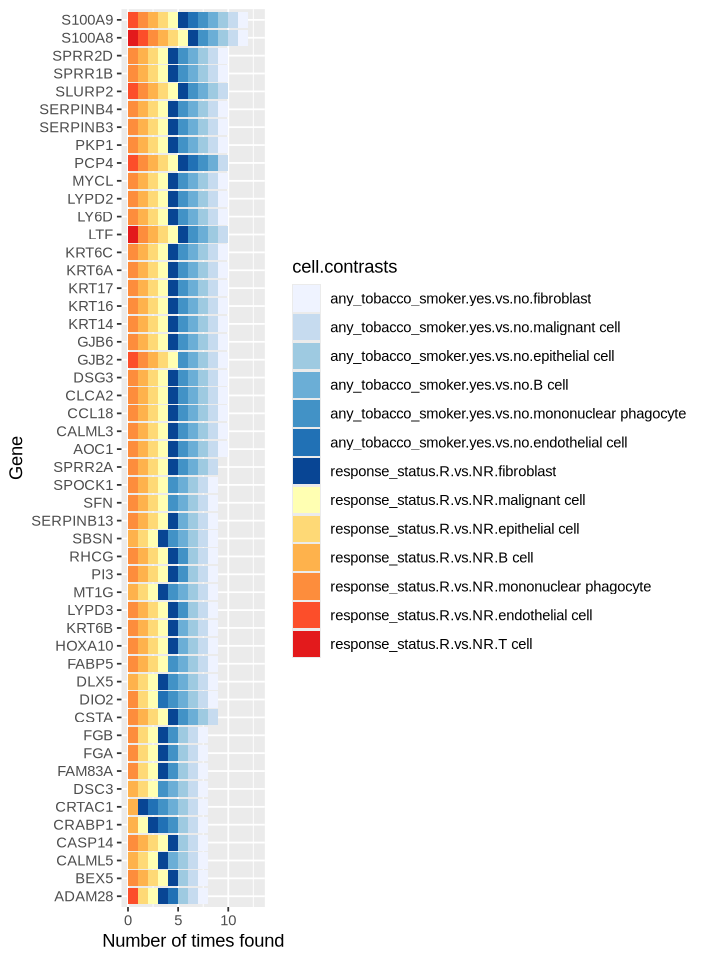

In [25]:
gg_tbl <- all.de %>% 
        group_by(Gene) %>%
        reframe(counts = n()) %>%
        arrange(-counts) %>%
        slice_head(n=50)

gg_tbl <- gg_tbl %>% arrange(counts)
temp <- all.de[all.de$Gene %in% gg_tbl$Gene,]
temp$Gene <-factor(temp$Gene, levels=gg_tbl$Gene)

options(repr.plot.width = 6, repr.plot.height=8)
cols <- c(brewer.pal('Blues',n=7),brewer.pal('YlOrRd',n=7))
p2 <- ggplot(temp,aes(x = Gene, 
                      y=1,
                   fill=cell.contrasts)) + 
            geom_bar(stat = 'identity', position='stack') +
            scale_fill_manual(values=cols) + scale_y_continuous(limits = c(0,13)) +
            coord_flip() + ylab('Number of times found') 
            

p2 

# head(gg_tbl)

## Make recurring DEG log2FC heatmap

In [49]:
head(all.de)

,Gene,p_val_adj,avg_log2FC,summary,pct.1,pct.2,contrast,cell.type,cell.contrasts
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<fct>
COLEC11,COLEC11,0,2.874940,any_tobacco_smoker.up.in.yes,0.164,0.029,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
PEG3,PEG3,0,2.528910,any_tobacco_smoker.up.in.yes,0.321,0.064,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
GREB1,GREB1,0,2.463457,any_tobacco_smoker.up.in.yes,0.238,0.090,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
TCF21,TCF21,0,2.440376,any_tobacco_smoker.up.in.yes,0.204,0.048,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
STAR,STAR,0,2.399962,any_tobacco_smoker.up.in.yes,0.140,0.026,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
KLHDC8A,KLHDC8A,0,2.371547,any_tobacco_smoker.up.in.yes,0.182,0.033,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast


In [98]:
temp <- master_palette
temp <- temp[!(names(temp) %in% c('plasmacytoid dendritic cell', "mast cell"))]

In [99]:
temp

malignant cell            fibroblast                B cell 
            "#E41A1C"             "#377EB8"             "#4DAF4A" 
      epithelial cell mononuclear phagocyte                T cell 
            "#984EA3"             "#FF7F00"             "#FFFF33" 
     endothelial cell 
            "#F781BF"

# Heatmap of most common DE genes

[1] 50 13

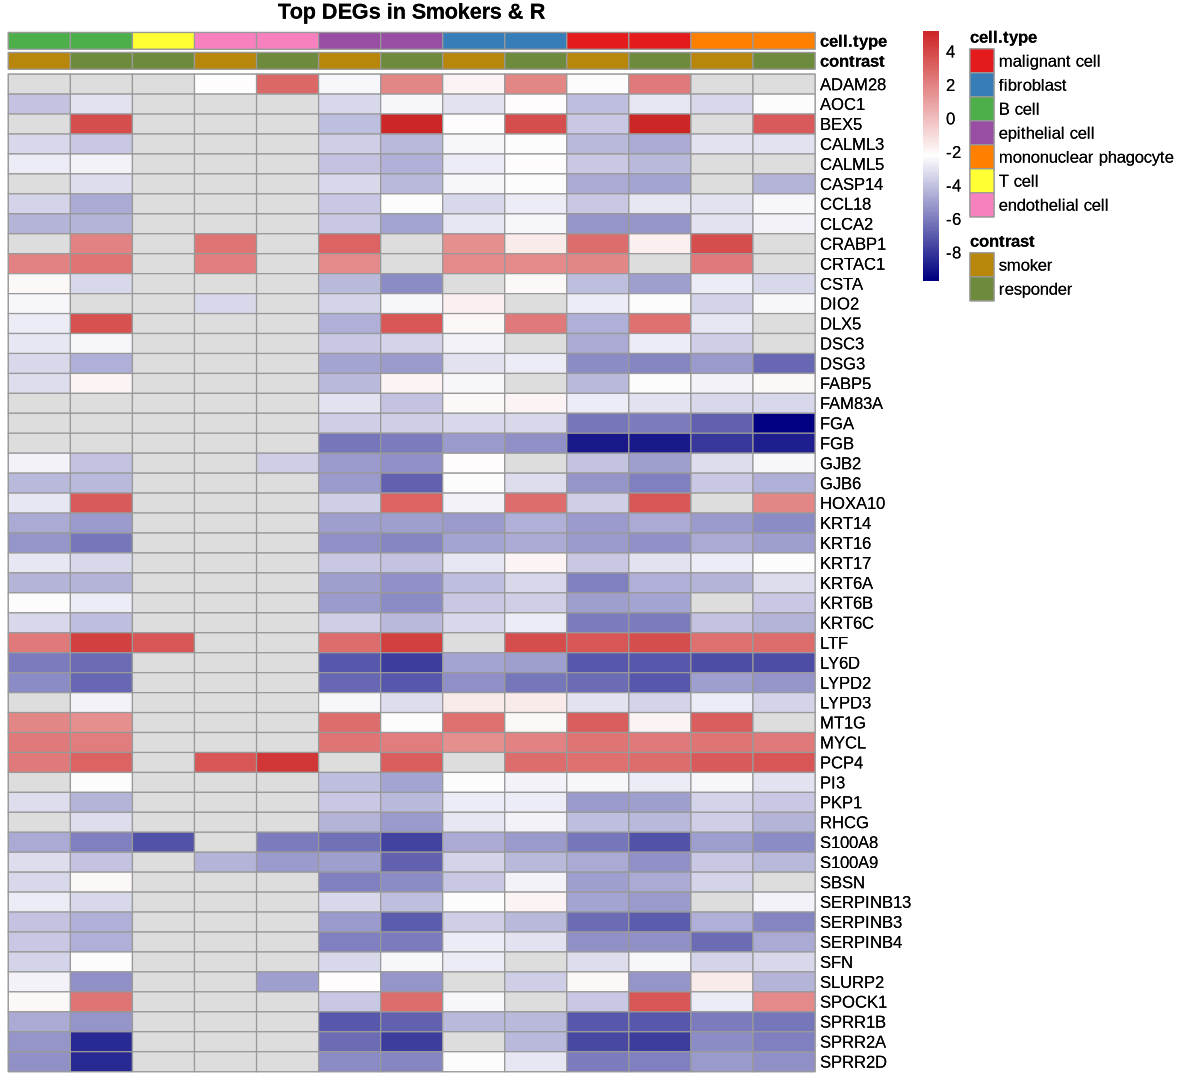

In [50]:
options(repr.plot.width=10,repr.plot.height=9)
gg_tbl <- all.de %>% 
        group_by(Gene) %>%
        reframe(counts = n()) %>%
        arrange(-counts) %>%
        slice_head(n=50)
use.genes <- gg_tbl$Gene
top.deg <- all.de %>% arrange(cell.type,contrast) %>%
            filter(Gene %in% use.genes) %>%
           select(Gene, avg_log2FC, cell.contrasts) %>%
           tidyr::pivot_wider(names_from=cell.contrasts,
                              id_cols = Gene,
                              values_from = avg_log2FC) %>%
           as.data.frame()
# top.deg[is.na(top.deg)] <- 0
row.names(top.deg) <- top.deg$Gene
top.deg <- top.deg %>% arrange(Gene)
top.deg$Gene <- NULL
top.deg <- as.matrix(top.deg)

dim(top.deg)
# giveNAs = which(is.na(as.matrix(dist(top.deg))),arr.ind=TRUE)
# tab = sort(table(c(giveNAs)),decreasing=TRUE)
# checkNA = sapply(1:length(tab),function(i){
#             sum(is.na(as.matrix(dist(top.deg[-as.numeric(names(tab[1:i])),]))))
# })
# rmv = names(tab)[1:min(which(checkNA==0))]
# print(paste('Remove',row.names(top.deg)[as.numeric(rmv)]))
# top.deg <- top.deg[-as.numeric(rmv),]
# dim(top.deg)
annotation_col <- data.frame(row.names = colnames(top.deg),
           contrast=stringr::str_split_i(colnames(top.deg),pattern = '\\.',i=1),
           cell.type= stringr::str_split_i(colnames(top.deg),pattern = '\\.',i=5))
annotation_col$contrast[grepl(pattern = 'response',annotation_col$contrast)] <- 'responder'
annotation_col$contrast[grepl(pattern = 'smoker',annotation_col$contrast)] <- 'smoker'
contrast_colors <- c("smoker" = "darkgoldenrod", 
                     "responder" = "darkolivegreen4")
levels <- c('malignant cell','fibroblast','B cell','epithelial cell','mononuclear phagocyte',
            'T cell','plasmacytoid dendritic cell','endothelial cell','mast cell')
master_palette <- setNames(brewer.pal(n = length(levels), "Set1"), levels)
use.palette <- master_palette[!(names(master_palette) %in% c('plasmacytoid dendritic cell', "mast cell"))]
ann_colors = list(contrast = contrast_colors,
                  cell.type = use.palette)                                                   
pheatmap.wrapper(top.deg, annotation_col, 
                 ann_colors, "Top DEGs in Smokers & R",
                cluster_rows=FALSE,cluster_cols=FALSE,
                 scale = "none"
                )

## Bubble plot of this

In [54]:
plot_data <- all.de %>% 
            filter(Gene %in% use.genes) 
head(plot_data)

,Gene,p_val_adj,avg_log2FC,summary,pct.1,pct.2,contrast,cell.type,cell.contrasts
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<fct>
MT1G,MT1G,4.160870e-68,2.575544,any_tobacco_smoker.up.in.smoker,0.038,0.009,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
CRTAC1,CRTAC1,2.269810e-60,1.661746,any_tobacco_smoker.up.in.smoker,0.055,0.021,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
MYCL,MYCL,1.902052e-36,1.619812,any_tobacco_smoker.up.in.smoker,0.064,0.034,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
CRABP1,CRABP1,1.052948e-83,1.528239,any_tobacco_smoker.up.in.smoker,0.113,0.055,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
LYPD3,LYPD3,2.119109e-20,-1.550035,any_tobacco_smoker.down.in.smoker,0.007,0.020,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast
DIO2,DIO2,1.074473e-41,-1.776399,any_tobacco_smoker.down.in.smoker,0.018,0.046,any_tobacco_smoker.yes.vs.no,fibroblast,any_tobacco_smoker.yes.vs.no.fibroblast


In [76]:
plot_data[idx,]

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,Gene,log2FC,p.adj,diffexpressed,delabel,contrast,cell.type,cell.contrasts,logpadj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<fct>,<fct>,<dbl>
PPP1R14A1,2.267173e-268,1.7512868,0.168,0.067,4.100183e-264,NA,1.7512868,4.100183e-264,UP,PPP1R14A,any_tobacco_smoker.yes.vs.no,malignant cell,any_tobacco_smoker.yes.vs.no.malignant cell,263.3871968
CLU1,0.000000e+00,1.1748055,0.944,0.831,0.000000e+00,NA,1.1748055,0.000000e+00,NO,NA,any_tobacco_smoker.yes.vs.no,malignant cell,any_tobacco_smoker.yes.vs.no.malignant cell,Inf
ATRNL11,7.798138e-33,1.0688271,0.073,0.047,1.410293e-28,NA,1.0688271,1.410293e-28,NO,NA,any_tobacco_smoker.yes.vs.no,malignant cell,any_tobacco_smoker.yes.vs.no.malignant cell,27.8506905
TRIT11,6.155667e-111,1.0008740,0.236,0.164,1.113252e-106,NA,1.0008740,1.113252e-106,NO,NA,any_tobacco_smoker.yes.vs.no,malignant cell,any_tobacco_smoker.yes.vs.no.malignant cell,105.9534063
ACTR3B1,1.442497e-41,1.0001381,0.086,0.055,2.608757e-37,NA,1.0001381,2.608757e-37,NO,NA,any_tobacco_smoker.yes.vs.no,malignant cell,any_tobacco_smoker.yes.vs.no.malignant cell,36.5835665
TRMT14,4.376909e-101,0.9636844,0.256,0.186,7.915641e-97,NA,0.9636844,7.915641e-97,NO,NA,any_tobacco_smoker.yes.vs.no,malignant cell,any_tobacco_smoker.yes.vs.no.malignant cell,96.1015139
ROR11,2.746767e-46,0.9291697,0.088,0.054,4.967529e-42,NA,0.9291697,4.967529e-42,NO,NA,any_tobacco_smoker.yes.vs.no,malignant cell,any_tobacco_smoker.yes.vs.no.malignant cell,41.3038596
PKP21,7.186721e-66,0.8141428,0.186,0.133,1.299718e-61,NA,0.8141428,1.299718e-61,NO,NA,any_tobacco_smoker.yes.vs.no,malignant cell,any_tobacco_smoker.yes.vs.no.malignant cell,60.8861507
AKT21,2.088747e-115,0.7227430,0.354,0.275,3.777499e-111,NA,0.7227430,3.777499e-111,NO,NA,any_tobacco_smoker.yes.vs.no,malignant cell,any_tobacco_smoker.yes.vs.no.malignant cell,110.4227957


[1] <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
[16] <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
[31] <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
[46] <NA> <NA> <NA> <NA> <NA>
Levels:

[1] <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
[16] <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
[31] <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA> <NA>
[46] <NA> <NA> <NA> <NA> <NA>
Levels:

In [ ]:
l

In [92]:
plot_data <- all %>% 
            filter(Gene %in% use.genes) %>%
            mutate(logpadj = -log10(p_val_adj))

mat <- plot_data %>% select(Gene, avg_log2FC, cell.contrasts) %>%
    tidyr::pivot_wider(names_from = cell.contrasts,
                       id_cols = Gene,
                       values_from = avg_log2FC) %>%
    as.data.frame()
row.names(mat) <- mat$Gene
mat %>% select(-Gene) %>%
    mutate(avg.gene = rowMeans(.,na.rm=TRUE)) %>% arrange(-avg.gene) %>%
    row.names()

[1] "CLU"      "TRIT1"    "ACTR3B"   "TRMT1"    "OBSL1"    "DPCD"    
 [7] "SELENBP1" "PITPNM3"  "FGFRL1"   "PPP1R14A" "ATRNL1"   "CP"      
[13] "NCDN"     "AKT2"     "PKP2"     "GOLGA7"   "HMGN3"    "ROR1"    
[19] "WASF3"    "PHF10"    "S100A13"  "WNT11"    "ISG15"    "TSPAN33" 
[25] "SLPI"     "ZNF124"   "KIF26B"   "FOSB"     "CBLB"     "BNIPL"   
[31] "MYT1"     "NBL1"     "ANXA3"    "SCX"      "C1QTNF1"  "ERO1A"   
[37] "SLC40A1"  "MAPK15"   "SEMA6A"   "HES4"     "BCL3"     "TMEM176A"
[43] "IL32"     "APOL2"    "CTHRC1"   "B2M"      "S100A4"   "ACSL1"   
[49] "LYZ"      "SELL"     "EPHA2"    "CD52"     "IGKC"     "IGHG1"   
[55] "MMP11"    "CXCL9"

[1] 721  14

[1] 721  14

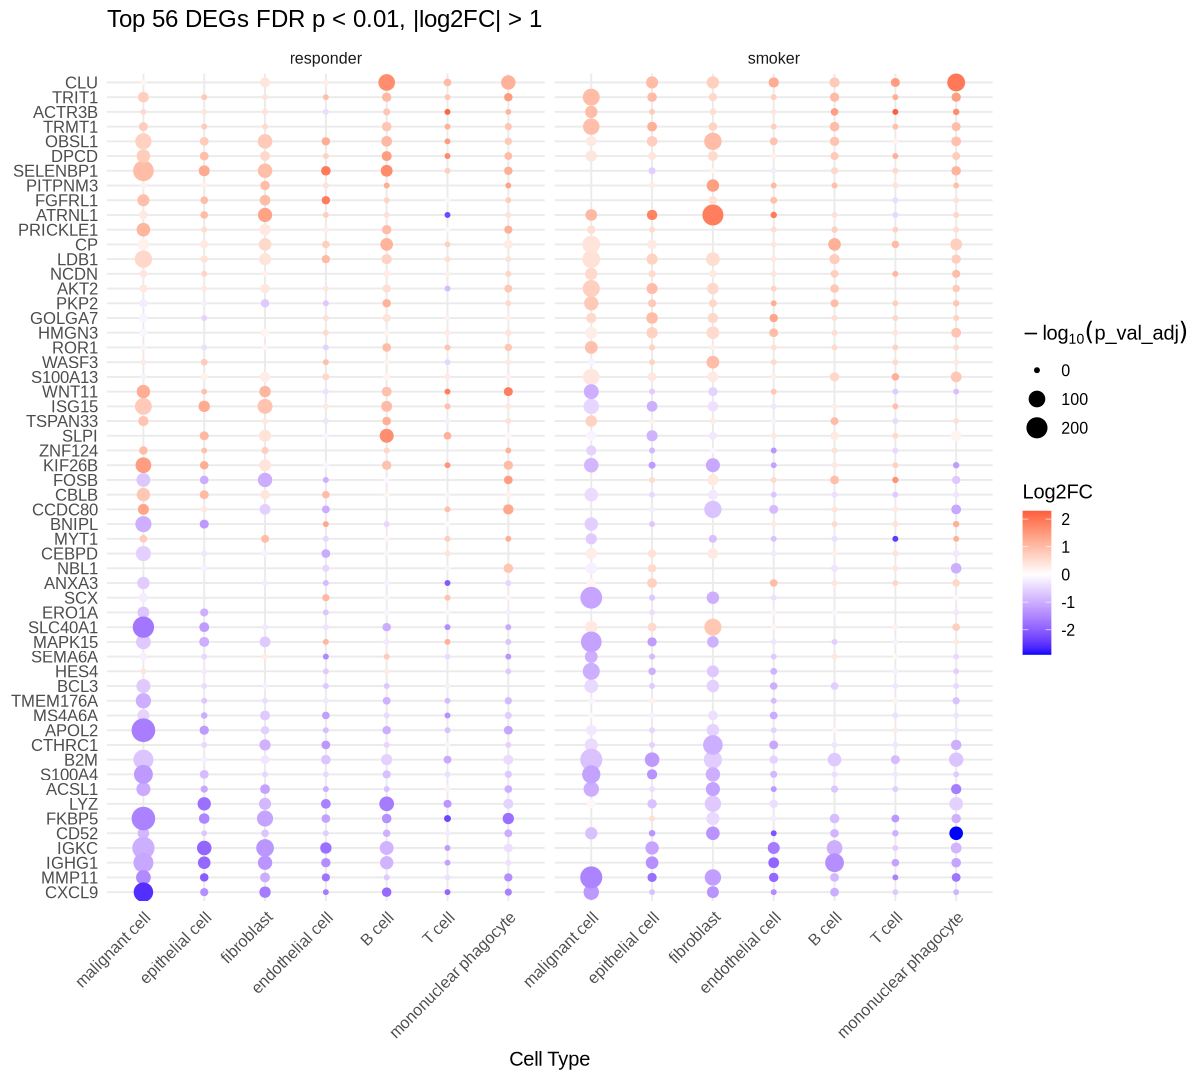

In [100]:
use.df <- all
clustering = TRUE
p.thresh = 0.01
top_pathways <- use.df %>%
  filter(p_val_adj < p.thresh) %>%
  filter(avg_log2FC > 1) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = -avg_log2FC, n =2) %>%
  ungroup() %>%
  distinct(Gene) %>%
  pull(Gene)

bottom_pathways <- use.df %>%
  filter(p_val_adj < p.thresh) %>%
  filter(avg_log2FC < -1) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = avg_log2FC, n = 2) %>%
  ungroup() %>%
  distinct(Gene) %>%
  pull(Gene)

use.genes <- unique(c(top_pathways,bottom_pathways))
plot_data <- all %>% 
            filter(Gene %in% use.genes) %>%
            mutate(logpadj = -log10(p_val_adj))
contrasts <- plot_data$contrast
contrasts[grepl(pattern='response',plot_data$contrast)] <- 'responder'
contrasts[grepl(pattern='tobacco',plot_data$contrast)] <- 'smoker'
plot_data$contrast <- factor(contrasts,
                           levels = c('responder', 'smoker'))
plot_data$cell.type <- factor(plot_data$cell.type,
                              levels = cell.types <- c('malignant cell','epithelial cell','fibroblast',
                                                       'endothelial cell',
                                                       'B cell','T cell',
                                                       'mononuclear phagocyte'))
dim(plot_data)
mat <- plot_data %>% select(Gene, avg_log2FC, cell.contrasts) %>%
    tidyr::pivot_wider(names_from = cell.contrasts,
                       id_cols = Gene,
                       values_from = avg_log2FC) %>%
    as.data.frame()
row.names(mat) <- mat$Gene
gene.levels <- mat %>% select(-Gene) %>%
    mutate(avg.gene = rowMeans(.,na.rm=TRUE)) %>% arrange(avg.gene) %>%
    row.names()
plot_data$Gene <- factor(plot_data$Gene,
                         levels = gene.levels)
dim(plot_data)
            # ,) #'plasmacytoid dendritic cell'
# Plot: pathways on Y, cell.type on X, dot shows NES & padj
ggplot(plot_data, aes(x = cell.type, y = Gene)) +
  geom_point(aes(size = logpadj, color = avg_log2FC)) +
  facet_wrap(~ contrast) +
  scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
  scale_size_continuous(range = c(1, 6)) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.y = element_text(size = 10),
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  labs(
    x = "Cell Type",
    y = NULL,
    size = expression(-log[10](p_val_adj)),
    color = "Log2FC",
    title = sprintf("Top %d DEGs FDR p < %1.2f, |log2FC| > 1",length(use.genes),p.thresh)
  )


[1] 364  14

[1] 364  14

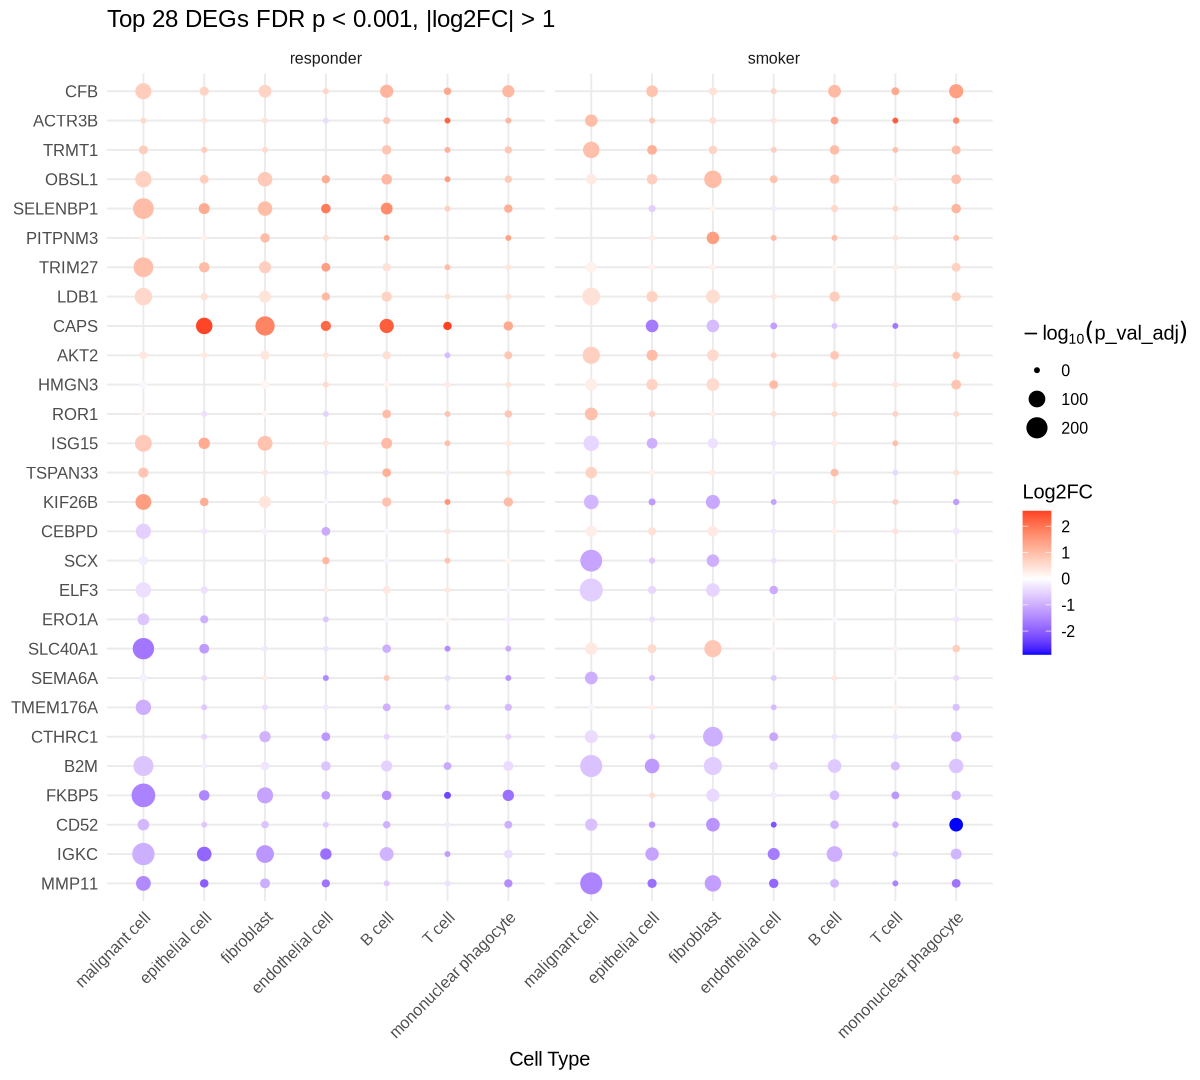

In [107]:
use.df <- all
clustering = TRUE
p.thresh = 0.001
top_pathways <- use.df %>%
  filter(p_val_adj < p.thresh) %>%
  filter(avg_log2FC > 1) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = -avg_log2FC, n =1) %>%
  ungroup() %>%
  distinct(Gene) %>%
  pull(Gene)

bottom_pathways <- use.df %>%
  filter(p_val_adj < p.thresh) %>%
  filter(avg_log2FC < -1) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = avg_log2FC, n = 1) %>%
  ungroup() %>%
  distinct(Gene) %>%
  pull(Gene)

use.genes <- unique(c(top_pathways,bottom_pathways))
plot_data <- all %>% 
            filter(Gene %in% use.genes) %>%
            mutate(logpadj = -log10(p_val_adj))
contrasts <- plot_data$contrast
contrasts[grepl(pattern='response',plot_data$contrast)] <- 'responder'
contrasts[grepl(pattern='tobacco',plot_data$contrast)] <- 'smoker'
plot_data$contrast <- factor(contrasts,
                           levels = c('responder', 'smoker'))
plot_data$cell.type <- factor(plot_data$cell.type,
                              levels = cell.types <- c('malignant cell','epithelial cell','fibroblast',
                                                       'endothelial cell',
                                                       'B cell','T cell',
                                                       'mononuclear phagocyte'))
dim(plot_data)
mat <- plot_data %>% select(Gene, avg_log2FC, cell.contrasts) %>%
    tidyr::pivot_wider(names_from = cell.contrasts,
                       id_cols = Gene,
                       values_from = avg_log2FC) %>%
    as.data.frame()
row.names(mat) <- mat$Gene
gene.levels <- mat %>% select(-Gene) %>%
    mutate(avg.gene = rowMeans(.,na.rm=TRUE)) %>% arrange(avg.gene) %>%
    row.names()
plot_data$Gene <- factor(plot_data$Gene,
                         levels = gene.levels)
dim(plot_data)
            # ,) #'plasmacytoid dendritic cell'
# Plot: pathways on Y, cell.type on X, dot shows NES & padj
ggplot(plot_data, aes(x = cell.type, y = Gene)) +
  geom_point(aes(size = logpadj, color = avg_log2FC)) +
  facet_wrap(~ contrast) +
  scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
  scale_size_continuous(range = c(1, 6)) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.y = element_text(size = 10),
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  labs(
    x = "Cell Type",
    y = NULL,
    size = expression(-log[10](p_val_adj)),
    color = "Log2FC",
    title = sprintf("Top %d DEGs FDR p < %1.3f, |log2FC| > 1",length(use.genes),p.thresh)
  )

In [34]:
all$cell.contrasts <- paste(all$contrast,all$cell.type,sep='.')
all$cell.contrasts <- factor(all$cell.contrasts,
                              levels= c('any_tobacco_smoker.yes.vs.no.fibroblast',
                                        'any_tobacco_smoker.yes.vs.no.malignant cell',
                                        'any_tobacco_smoker.yes.vs.no.epithelial cell',
                                        'any_tobacco_smoker.yes.vs.no.B cell',
                                        'any_tobacco_smoker.yes.vs.no.mononuclear phagocyte',
                                        'any_tobacco_smoker.yes.vs.no.endothelial cell',
                                        'any_tobacco_smoker.yes.vs.no.T cell',
                                        'response_status.R.vs.NR.fibroblast',
                                        'response_status.R.vs.NR.malignant cell',
                                        'response_status.R.vs.NR.epithelial cell',
                                        'response_status.R.vs.NR.B cell',
                                        'response_status.R.vs.NR.mononuclear phagocyte',
                                        'response_status.R.vs.NR.endothelial cell',
                                        'response_status.R.vs.NR.T cell'))

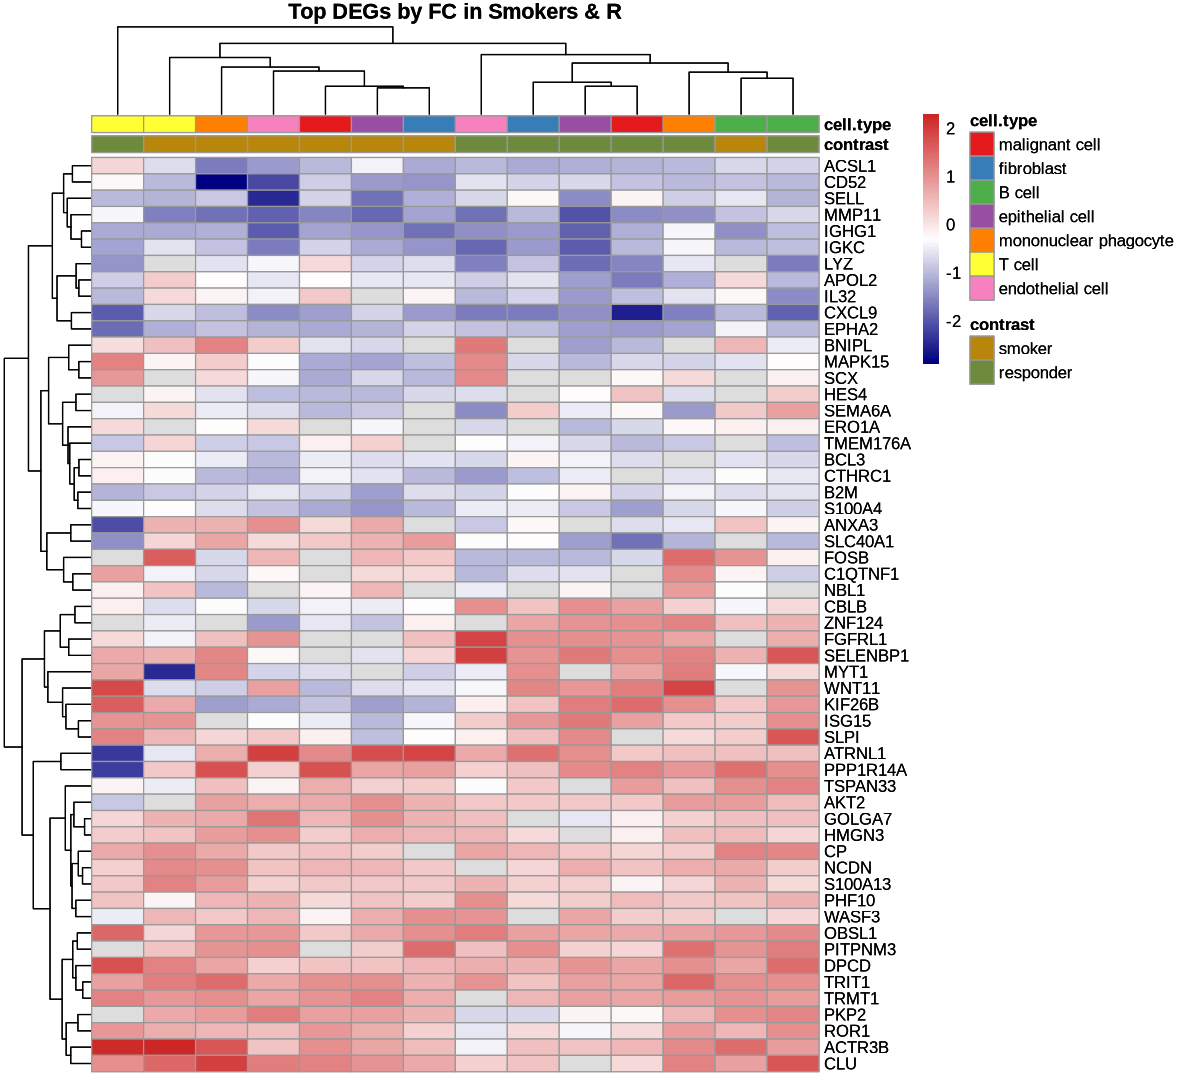

In [109]:
options(repr.plot.width=10,repr.plot.height=9)
use.df <- all
clustering = TRUE
top_pathways <- use.df %>%
  filter(p_val_adj < 0.05) %>%
  filter(avg_log2FC > 1) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = -avg_log2FC, n =2) %>%
  ungroup() %>%
  distinct(Gene) %>%
  pull(Gene)

bottom_pathways <- use.df %>%
  filter(p_val_adj < 0.05) %>%
  filter(avg_log2FC < -1 ) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = avg_log2FC, n = 2) %>%
  ungroup() %>%
  distinct(Gene) %>%
  pull(Gene)

use.genes <- unique(c(top_pathways,bottom_pathways))
top.deg <- use.df  %>% arrange(cell.type,contrast) %>%
            filter(Gene %in% use.genes) %>%
           select(Gene, avg_log2FC, cell.contrasts) %>%
           tidyr::pivot_wider(names_from=cell.contrasts,
                              id_cols = Gene,
                              values_from = avg_log2FC) %>%
           as.data.frame()
# top.deg[is.na(top.deg)] <- 0
row.names(top.deg) <- top.deg$Gene
top.deg <- top.deg %>% arrange(Gene)
top.deg$Gene <- NULL
top.deg <- as.matrix(top.deg)

annotation_col <- data.frame(row.names = colnames(top.deg),
           contrast=stringr::str_split_i(colnames(top.deg),pattern = '\\.',i=1),
           cell.type= stringr::str_split_i(colnames(top.deg),pattern = '\\.',i=5))
annotation_col$contrast[grepl(pattern = 'response',annotation_col$contrast)] <- 'responder'
annotation_col$contrast[grepl(pattern = 'smoker',annotation_col$contrast)] <- 'smoker'
contrast_colors <- c("smoker" = "darkgoldenrod", 
                     "responder" = "darkolivegreen4")
levels <- c('malignant cell','fibroblast','B cell','epithelial cell','mononuclear phagocyte',
            'T cell','plasmacytoid dendritic cell','endothelial cell','mast cell')
master_palette <- setNames(brewer.pal(n = length(levels), "Set1"), levels)
use.palette <- master_palette[!(names(master_palette) %in% c('plasmacytoid dendritic cell', "mast cell"))]
ann_colors = list(contrast = contrast_colors,
                  cell.type = use.palette)                                                   
pheatmap.wrapper(top.deg, annotation_col, 
                 ann_colors, "Top DEGs by FC in Smokers & R",
                cluster_rows=clustering,
                 cluster_cols=clustering,
                 scale = "none"
                )

# Pseudobulk cell-wise DE

In [46]:
# pseudobulk the counts based on donor-condition-celltype
suppressWarnings({
pseudo_dat <- AggregateExpression(dat, assays = "Spatial", return.seurat = T, 
                                  group.by = c("any_tobacco_smoker", "cgf.sample.id", "predicted.id"))
})
pseudo_dat$celltype.smoker <- paste(stringr::str_replace_all(pseudo_dat$predicted.id,
                                                           ' ','_'),
                                  pseudo_dat$any_tobacco_smoker, sep = "_")
Idents(pseudo_dat) <- "celltype.smoker"

bulk.mono.de <- FindMarkers(object = pseudo_dat, 
                         ident.1 = "malignant_cell_yes", 
                         ident.2 = "malignant_cell_no",
                         base = 2,
                         min.pct = 0.1,
                         test.use = "DESeq2")
head(bulk.mono.de, n = 15)

Removing cells with NA for 1 or more grouping variables
Centering and scaling data matrix



[1] "no_25-0092_epithelial cell"            
[2] "no_25-0092_fibroblast"                 
[3] "no_25-0092_malignant cell"             
[4] "no_25-0092_mononuclear phagocyte"      
[5] "no_25-0092_plasmacytoid dendritic cell"
[6] "no_25-0092_T cell"

In [9]:
any(!is.na(p2))

[1] TRUE

[1] "fibroblast"            "malignant cell"        "epithelial cell"      
[4] "B cell"                "mononuclear phagocyte" "endothelial cell"     
[7] "T cell"               


Removing cells with NA for 1 or more grouping variables
Centering and scaling data matrix



[1] "Loading any_tobacco_smoker.yes.vs.no.fibroblast.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


Warning message:
“Removed 502 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18052 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 502 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18052 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


[1] "18056 18085 18056" "11 26 18056"      
[1] "Loading any_tobacco_smoker.yes.vs.no.malignant.cell.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


Warning message:
“Removed 908 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18051 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 908 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18051 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


[1] "18061 18085 18061" "11 26 18061"      
[1] "Loading any_tobacco_smoker.yes.vs.no.epithelial.cell.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


Warning message:
“Removed 368 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18031 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 368 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18031 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


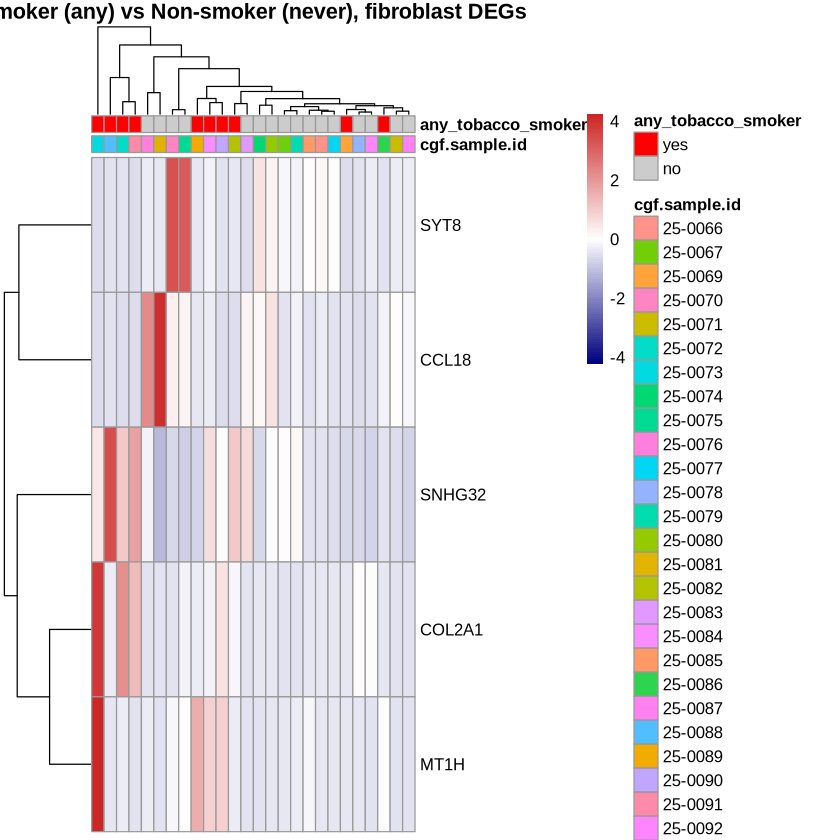

[1] "18032 18085 18032" "11 26 18032"      
[1] "Too few genes or samples for heatmap."
[1] "Generating any_tobacco_smoker.yes.vs.no.B.cell.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

Warning message:
“Removed 214 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18035 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 214 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18035 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


[1] "18035 18085 18035" "11 26 18035"      
[1] "Too few genes or samples for heatmap."
[1] "Generating any_tobacco_smoker.yes.vs.no.mononuclear.phagocyte.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

Warning message:
“Removed 311 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18023 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 311 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18023 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


[1] "18024 18085 18024" "11 26 18024"      
[1] "Too few genes or samples for heatmap."
[1] "Generating any_tobacco_smoker.yes.vs.no.endothelial.cell.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


...

[1] "17847 18085 17847" "11 26 17847"      
[1] "Too few genes or samples for heatmap."
[1] "Generating any_tobacco_smoker.yes.vs.no.T.cell.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

Warning message:
“Removed 81 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 17566 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 81 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 17566 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


[1] "17566 18085 17566" "11 26 17566"      
[1] "Too few genes or samples for heatmap."
[1] "Generating any_tobacco_smoker.yes.vs.no.all.cells.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

Warning message:
“Removed 396 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 17846 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“ggrepel: 170 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“Removed 396 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 17846 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“ggrepel: 169 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "18045 18085 18045" "11 197 18045"     


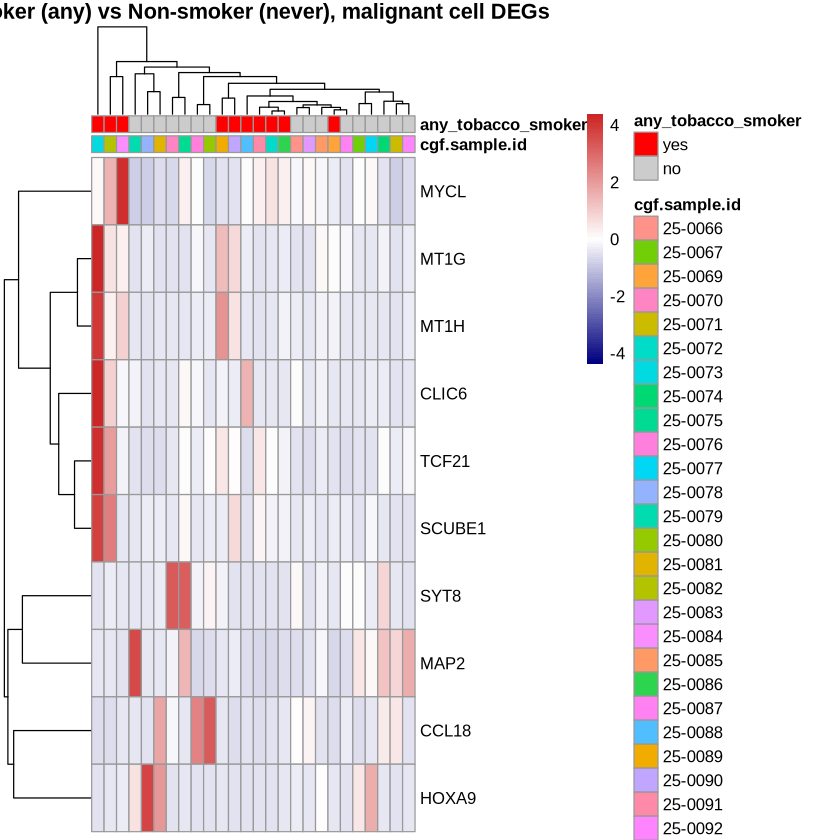

Removing cells with NA for 1 or more grouping variables
Centering and scaling data matrix



[1] "Generating response_status.R.vs.NR.fibroblast.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

Warning message:
“Removed 464 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18052 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 464 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18052 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


[1] "18053 18085 18053" "11 18 18053"      
[1] "Too few genes or samples for heatmap."
[1] "Generating response_status.R.vs.NR.malignant.cell.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

Warning message:
“Removed 672 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18053 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 672 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18053 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


[1] "18058 18085 18058" "11 18 18058"      


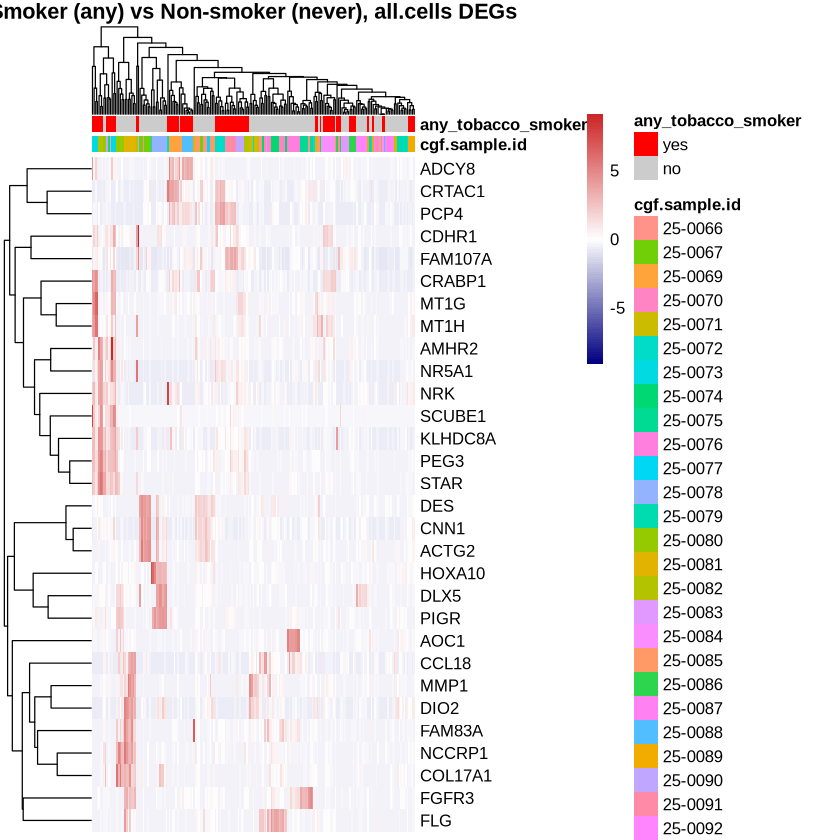

[1] "Generating response_status.R.vs.NR.epithelial.cell.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

Warning message:
“Removed 331 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18021 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 331 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18021 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


[1] "18021 18085 18021" "11 18 18021"      
[1] "Too few genes or samples for heatmap."
[1] "Generating response_status.R.vs.NR.B.cell.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

Warning message:
“Removed 190 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18018 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 190 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 18018 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


[1] "18020 18085 18020" "11 18 18020"      


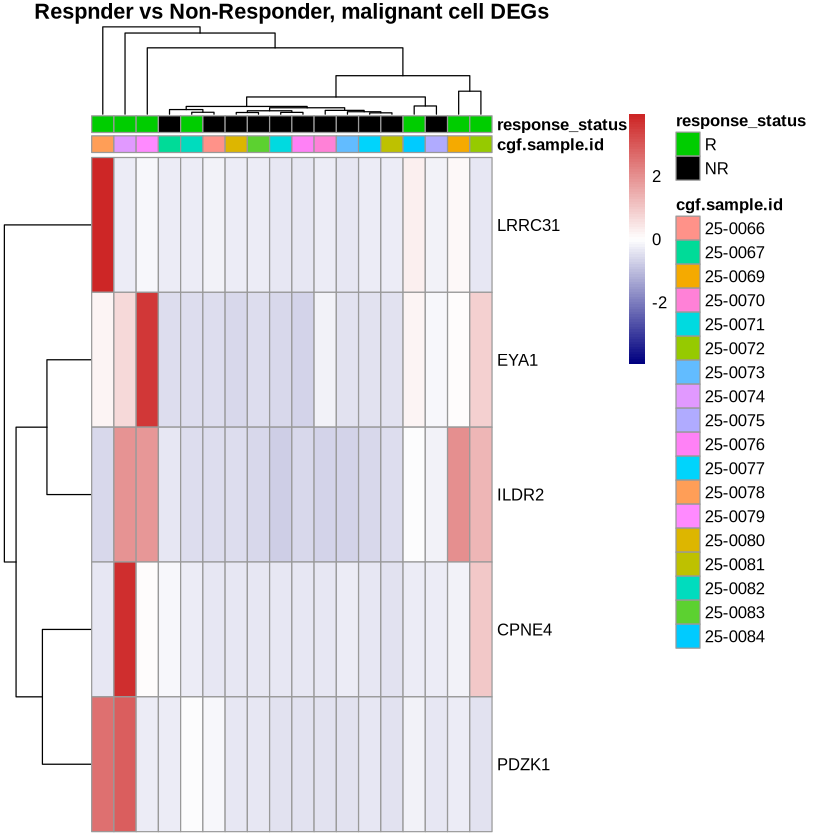

[1] "Generating response_status.R.vs.NR.mononuclear.phagocyte.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

Warning message:
“Removed 274 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 17989 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 274 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 17989 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


[1] "17990 18085 17990" "11 18 17990"      
[1] "Too few genes or samples for heatmap."
[1] "Generating response_status.R.vs.NR.endothelial.cell.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

Warning message:
“Removed 132 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 17670 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 132 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 17670 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


[1] "17670 18085 17670" "11 18 17670"      
[1] "Too few genes or samples for heatmap."
[1] "Generating response_status.R.vs.NR.T.cell.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 16200 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 16200 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


[1] "16200 18085 16200" "11 18 16200"      
[1] "Too few genes or samples for heatmap."
[1] "Generating response_status.R.vs.NR.all.cells.pseudobulk.DEG.p0.100.log.1.0.DESeq2.v1.csv"


converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

Warning message:
“Removed 401 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 17869 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“ggrepel: 139 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“Removed 401 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 17869 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“ggrepel: 138 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "18041 18085 18041" "11 134 18041"     


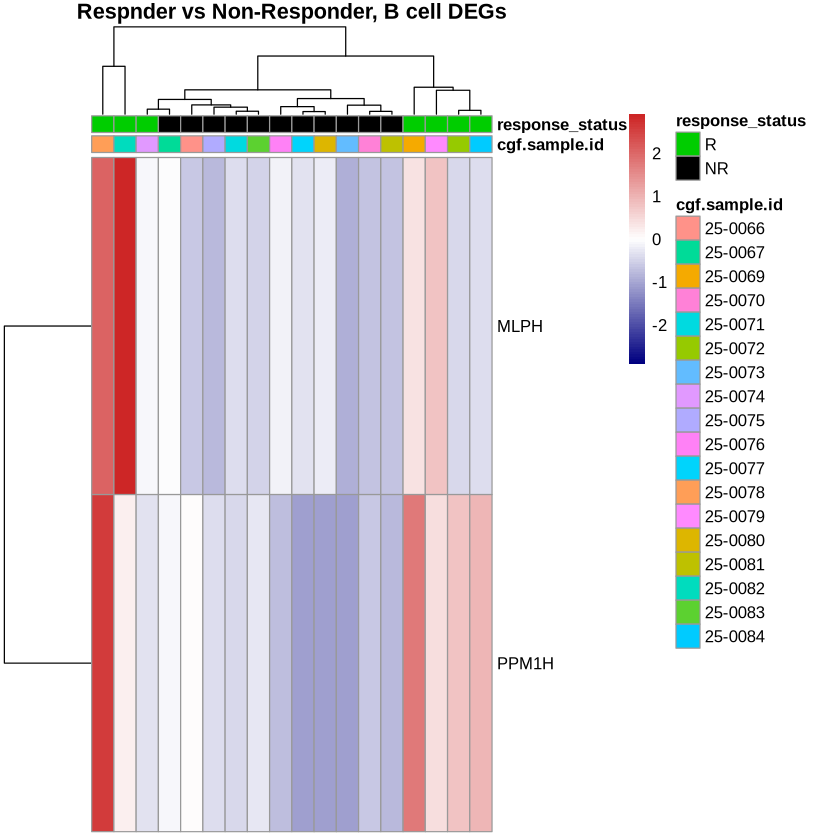

   user  system elapsed 
204.483   1.557 211.292 

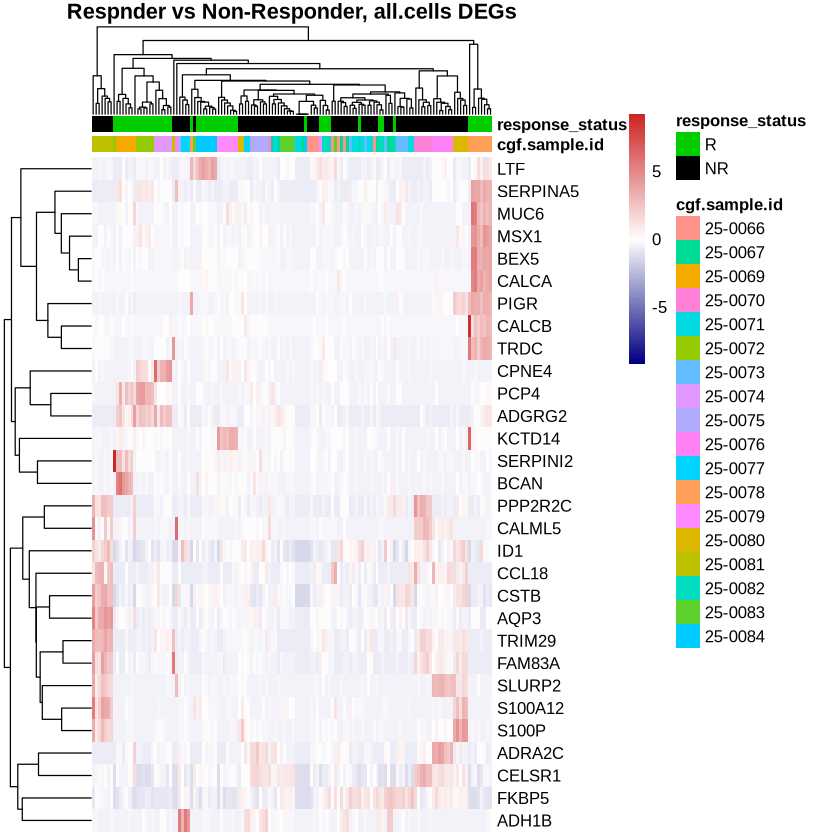

In [10]:
cell.types <- unique(dat@meta.data$predicted.id)
cell.types <-  cell.types[!(cell.types %in% c('plasmacytoid dendritic cell', 'mast cell'))] #too few
print(cell.types)
# cell.types <- c('malignant cell')
cell.types <- c(cell.types,'all.cells')
use.tags <- c( 'any_tobacco_smoker'  , 'response_status')
test <- 'DESeq2'
log.name <- "avg_log2FC"
p.name <- 'p_val_adj'
p = 0.1
log_thresh = 1
width = 8
height = 6
suppressWarnings({
    out.gene.lists <- file.path(results,sprintf('pseudobulk_DEG_contrasts_%s',test),'csv')
    dir.create(out.gene.lists,recursive = TRUE)
    out.de.volcano <- file.path(results,sprintf('pseudobulk_DEG_contrasts_%s',test),'volcano')
    dir.create(out.de.volcano,recursive=TRUE)
    out.de.heatmap <- file.path(results,sprintf('pseudobulk_DEG_contrasts_%s',test),'heatmap')
    dir.create(out.de.heatmap,recursive=TRUE)
})
plot.volc <- TRUE
plot.heat <- TRUE
system.time({
    for (tag in use.tags){
        if (tag == 'response_status'){
            idents <- c('R','NR')
           
        }else{
            idents <- c('yes','no')
        }
        suppressWarnings({
            pseudo_dat <- AggregateExpression(dat, assays = "Spatial", return.seurat = T, 
                                              group.by = c(tag, "cgf.sample.id", "predicted.id"))
            # pseudo_dat@meta.data[, ideally: merge in excluded tag meta.data as well
        })
        for (cell in cell.types){
            if (tag == 'response_status'){
                 title = sprintf('Respnder vs Non-Responder, %s DEGs',cell)
            } else{
                 title = sprintf('Smoker (any) vs Non-smoker (never), %s DEGs',cell)
            }
            if (cell != 'all.cells'){
                suppressWarnings({sub <- subset(pseudo_dat,subset = predicted.id == cell)})
            } else {
                sub <- pseudo_dat
            }
            DefaultAssay(sub) <- "Spatial"
            Idents(sub) <- tag  
            contrast.str <- paste0(tag,'.',idents[1],'.vs.',idents[2])
            base.fn <- sprintf('%s.%s.pseudobulk.DEG.p%1.3f.log.%1.1f.%s.v1',contrast.str,cell,p,log_thresh,test)
            base.fn <- stringr::str_replace_all(base.fn,' ','.')
            fn=paste0(base.fn,'.csv')            
            if (file.exists(file.path(out.gene.lists,fn))){
                print(paste('Loading',fn))
                de <- read.csv(file.path(out.gene.lists,fn),row.names=1)
            }else{
                print(paste('Generating',fn))            
                markers <- FindMarkers(object=sub,
                                     ident.1 = idents[1],   
                                     ident.2 = idents[2],      
                                     base=2,
                                    min.pct = 0.1,
                                    test.use = test)# 'negbinom', #'wilcox_limma',#'MAST', #
                                    # latent.vars = c('cgf.sample.id','response_status','group'), #For models that accept: 'LR', 'negbinom', 'poisson', or 'MAST')
                de <- markers
                de$Gene <- row.names(markers)         
                de$log2FC <- de[[log.name]]         
                de$p.adj <- de[[p.name]]
                de$diffexpressed <- "NO"    
                de$diffexpressed[de$log2FC > log_thresh & de$p.adj < p] <- "UP"
                de$diffexpressed[de$log2FC < -log_thresh & de$p.adj < p] <- "DOWN"
                de$delabel <- NA
                de$delabel[de$diffexpressed != "NO"] <- de$Gene[de$diffexpressed != "NO"]
                de <- de %>% arrange(-log2FC,p_val_adj)               
                de$contrast <- contrast.str 
                fn=paste0(base.fn,'.csv')
                write.csv(de,file.path(out.gene.lists,fn))
            }
            if (plot.volc){
                p1 <- volcano.plot(de, p, log_thresh, title)
                save.figs(p1, out.de.volcano, base.fn, width=width, height=height)
            }
            if (plot.heat){
                if (cell == 'T cell'){
                    ds.pt = 10
                    ndeg = 10
                } else {
                    ds.pt =100
                    ndeg = 15
                }
                print(paste(dim(de),dim(sub),sum(row.names(de) %in% row.names(sub))))
                p2 <- heatmap.plot(de, sub,title ,ndeg_top_bottom = ndeg,p.thresh=p ,
                                   ds.pt =ds.pt,plot.tag=c(tag))
                if (any(!is.na(p2))){
                    save.figs(p2, out.de.heatmap, base.fn,
                          width=10, height=5)
                }else{
                    print('Too few genes or samples for heatmap.')
                }
            }
        }
    }
})


fix heatmap error with T cell!

## Collect DEGs (pseudo-bulk)

In [42]:
cell.types <- unique(dat@meta.data$predicted.id)
cell.types <-  cell.types[!(cell.types %in% c('plasmacytoid dendritic cell', 'mast cell'))] #too few
print(cell.types)
cell.types <- c(cell.types)
use.tags <- c( 'any_tobacco_smoker'  , 'response_status')
test <- 'DESeq2'
log.name <- "avg_log2FC"
p.name <- 'p_val_adj'
p = 0.1
log_thresh = 1
out.gene.lists <- file.path(results,sprintf('pseudobulk_DEG_contrasts_%s',test),'csv')
all.de <- data.frame(c())
for (tag in use.tags){
    if (tag == 'response_status'){
        idents <- c('R','NR')
       
    }else{
        idents <- c('yes','no')
    }
    for (cell in cell.types){
        if (tag == 'response_status'){
             title = sprintf('Respnder vs Non-Responder, %s DEGs',cell)
        } else{
             title = sprintf('Smoker (any) vs Non-smoker (never), %s DEGs',cell)
        }
        contrast.str <- paste0(tag,'.',idents[1],'.vs.',idents[2])
        base.fn <- sprintf('%s.%s.pseudobulk.DEG.p%1.3f.log.%1.1f.%s.v1',contrast.str,cell,p,log_thresh,test)
        base.fn <- stringr::str_replace_all(base.fn,' ','.')
        fn=paste0(base.fn,'.csv')
        summary.col <- paste0(tag,'.up.in.',idents[1])
        de <- read.csv(file.path(out.gene.lists,fn),row.names=1)
        summary.up <- paste0(tag,'.up.in.',idents[1])
        summary.down <- paste0(tag,'.down.in.',idents[1])
        filt.de <- de %>% filter(p_val_adj < 0.1) %>%
            mutate(summary = ifelse(avg_log2FC>0, summary.up, summary.down)) %>%  
            select(Gene,p_val_adj,avg_log2FC,summary,pct.1,pct.2,contrast) 
        if (dim(filt.de)[1] >0){
            filt.de$cell.type = cell
            all.de <- rbind(all.de,filt.de)
        }
    }
}
all.de          

[1] "fibroblast"            "malignant cell"        "epithelial cell"      
[4] "B cell"                "mononuclear phagocyte" "endothelial cell"     
[7] "T cell"               


,Gene,p_val_adj,avg_log2FC,summary,pct.1,pct.2,contrast,cell.type
,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>
COL2A1,COL2A1,6.047258e-03,1.9619960,any_tobacco_smoker.up.in.yes,1.000,0.750,any_tobacco_smoker.yes.vs.no,fibroblast
SNHG32,SNHG32,5.271325e-02,1.8743436,any_tobacco_smoker.up.in.yes,1.000,1.000,any_tobacco_smoker.yes.vs.no,fibroblast
MT1H,MT1H,6.895747e-02,1.4195521,any_tobacco_smoker.up.in.yes,1.000,1.000,any_tobacco_smoker.yes.vs.no,fibroblast
SYT8,SYT8,1.452043e-02,-0.9667525,any_tobacco_smoker.down.in.yes,0.700,1.000,any_tobacco_smoker.yes.vs.no,fibroblast
CCL18,CCL18,5.941345e-02,-1.8052286,any_tobacco_smoker.down.in.yes,0.900,0.938,any_tobacco_smoker.yes.vs.no,fibroblast
MT1G,MT1G,2.239206e-03,3.1287498,any_tobacco_smoker.up.in.yes,1.000,1.000,any_tobacco_smoker.yes.vs.no,malignant cell
MT1H1,MT1H,5.915826e-09,2.4734751,any_tobacco_smoker.up.in.yes,1.000,1.000,any_tobacco_smoker.yes.vs.no,malignant cell
MYCL,MYCL,6.054064e-02,1.9215883,any_tobacco_smoker.up.in.yes,1.000,1.000,any_tobacco_smoker.yes.vs.no,malignant cell
CLIC6,CLIC6,1.718941e-02,1.7995328,any_tobacco_smoker.up.in.yes,1.000,1.000,any_tobacco_smoker.yes.vs.no,malignant cell


In [44]:
fn <- sprintf('%d.smoker.resp.pseudobulk.topDEG.csv',dim(all.de)[1])
fnpn <- file.path(out.gene.lists,fn)
print(fnpn)
write.csv(all.de,fnpn)

[1] "/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/results/visium/pseudobulk_DEG_contrasts_DESeq2/csv/27.smoker.resp.pseudobulk.topDEG.csv"


In [46]:
length(unique(row.names(all.de)))

[1] 27

In [53]:
suppressWarnings({sub<-AggregateExpression(dat, assays = "Spatial", return.seurat = T, 
                          group.by = c("response_status","any_tobacco_smoker","cgf.sample.id"))
                })

Removing cells with NA for 1 or more grouping variables
Centering and scaling data matrix



## Pseudobulk heatmap of top DEGs

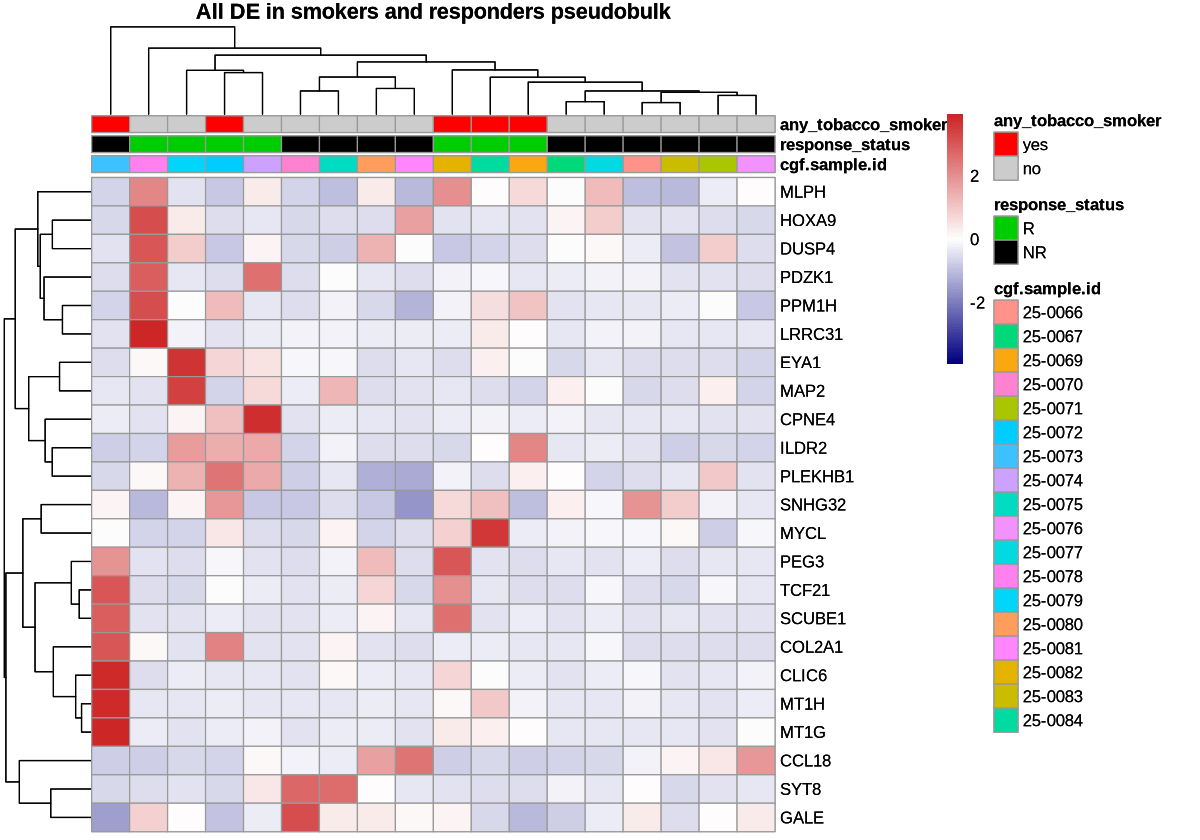

In [69]:
options(repr.plot.width=10,repr.plot.height=7)
p2 <- heatmap.plot(all.de, sub,'All DE in smokers and responders pseudobulk',ndeg_top_bottom = 50,p.thresh=0.1 ,
                                   ds.pt =1,plot.tag=c("response_status","any_tobacco_smoker"))
p2